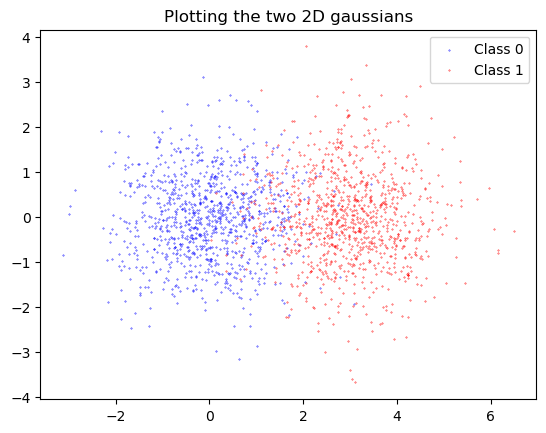

In [21]:
#Question number 1 from Homework 1
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
mean1 = [0,0]
mean2 = [3,0]
covariance = [[1,0],[0,1]]
N_value = 1000
x_values1, y_values1 = np.random.multivariate_normal(mean1, covariance, N_value).T
x_values2, y_values2 = np.random.multivariate_normal(mean2, covariance, N_value).T

fig, ax = plt.subplots()

plt.scatter(x_values1, y_values1, c='b', label='Class 0', s=0.1)
plt.scatter(x_values2, y_values2, c='r', label='Class 1', s=0.1)
plt.title('Plotting the two 2D gaussians')
plt.legend()
plt.show()

In [65]:
#Question Number 2 for Homework 4
#Need to reformat the data to match what we need it to be.
testx1 = x_values1[0:250]
testy1 = y_values1[0:250]
testx2 = x_values2[0:250]
testy2 = y_values2[0:250]
classarray = np.concatenate( (np.zeros(len(x_values1)), np.ones(len(x_values2)))).astype(int)
datalist = []
for i in np.arange(len(x_values1)):
    datalist.append(np.array([x_values1[i],y_values1[i]]))

for j in np.arange(len(x_values2)):
    datalist.append(np.array([x_values2[j],y_values2[j]]))
    
dataarray = np.array(datalist)
#Get test data. I took a fifth of the data to be my test data.
test_data = dataarray
test_class = classarray
#Fit test data.
clf_lr = LogisticRegression()
clf_lr.fit(test_data, test_class)

print(f"Weights w = {clf_lr.coef_[0]}")
print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
print(f"Accuracy = {clf_lr.score(test_data, test_class):.2%}")



Weights w = [3.01377868 0.00340078]
Bias    b = -4.432
Accuracy = 93.05%


In [54]:
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    # predict probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    # plot
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    
    colors = ['tab:blue', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)
    
    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='P(class 1)')
    return ax

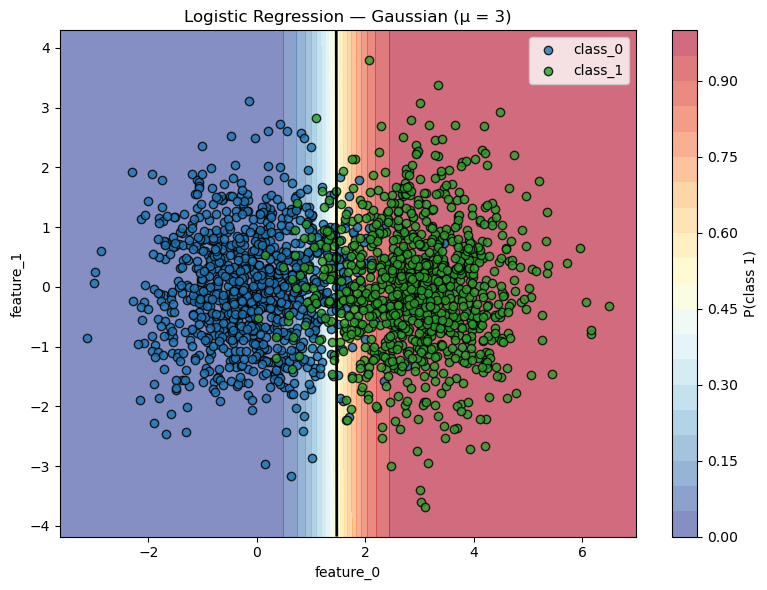

In [66]:
from sklearn.utils import Bunch

my_dataset = Bunch(
    data=test_data,
    target=test_class,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )

plot_decision_boundary(
    clf_lr, test_data, test_class,
    title='Logistic Regression — Gaussian (μ = 3)',
    feature_names= my_dataset.feature_names[:2],
    class_names=list(my_dataset.target_names[:2])
    )
plt.tight_layout()
plt.show()

In [76]:
#Problem three for Homework four.
#Now plot the μ values being 2, 1, 0.5
#But first for μ = 3, we need the false positive and false negative rates. 
from sklearn.metrics import confusion_matrix
class_pred = clf_lr.predict(test_data)
cm = confusion_matrix(test_class, class_pred)
print('For μ = 3')
print(cm)
print('False Positive rate',cm[0,1]/np.sum(cm))
print('False Negative rate',cm[1,0]/np.sum(cm))
print(f"Accuracy = {clf_lr.score(test_data, test_class):.2%}")
clf_lr.score(test_data, test_class)
accuracy_array = np.zeros(4)
accuracy_array[0] = clf_lr.score(test_data, test_class)
mean_array = np.array([3,2,1,0.5])

For μ = 3
[[931  69]
 [ 70 930]]
False Positive rate 0.0345
False Negative rate 0.035
Accuracy = 93.05%


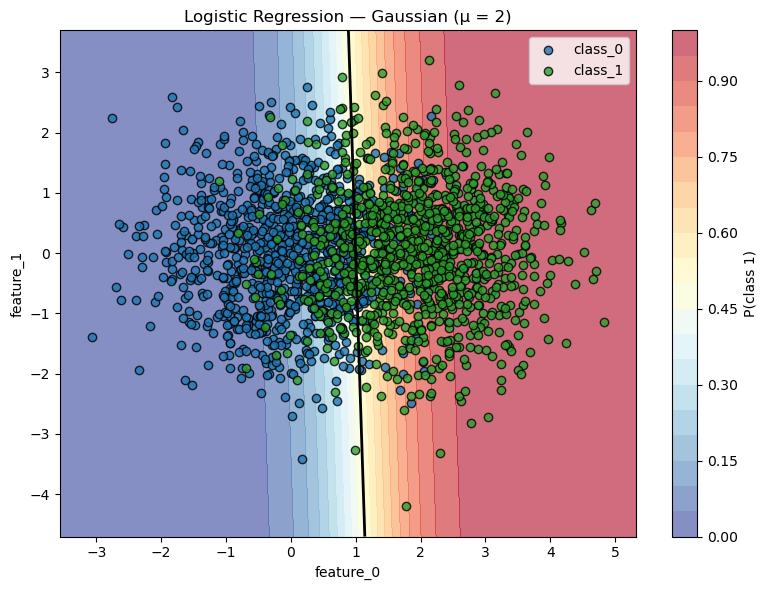

For μ = 2
[[848 152]
 [161 839]]
False Positive rate 0.076
False Negative rate 0.0805
Accuracy = 84.35%


In [82]:
#μ = 2

mean3 = [2,0]
N_value = 1000
x_values3, y_values3 = np.random.multivariate_normal(mean1, covariance, N_value).T
x_values4, y_values4 = np.random.multivariate_normal(mean3, covariance, N_value).T

classarray1 = np.concatenate( (np.zeros(len(x_values3)), np.ones(len(x_values4)))).astype(int)
datalist1 = []
for i in np.arange(len(x_values3)):
    datalist1.append(np.array([x_values3[i],y_values3[i]]))

for j in np.arange(len(x_values4)):
    datalist1.append(np.array([x_values4[j],y_values4[j]]))
    
dataarray1 = np.array(datalist1)
#Get test data. I took a fifth of the data to be my test data.
test_data1 = dataarray1
test_class1 = classarray1
#Fit test data.
clf_lr1 = LogisticRegression()
clf_lr1.fit(test_data1, test_class1)

#print(f"Weights w = {clf_lr.coef_[0]}")
#print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
#print(f"Accuracy = {clf_lr1.score(test_data1, test_class1):.2%}")

my_dataset1 = Bunch(
    data=test_data1,
    target=test_class1,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )

plot_decision_boundary(
    clf_lr1, test_data1, test_class1,
    title='Logistic Regression — Gaussian (μ = 2)',
    feature_names= my_dataset1.feature_names[:2],
    class_names=list(my_dataset1.target_names[:2])
    )
plt.tight_layout()
plt.show()

class_pred1 = clf_lr1.predict(test_data1)
cm1 = confusion_matrix(test_class1, class_pred1)
print('For μ = 2')
print(cm1)
print('False Positive rate',cm1[0,1]/np.sum(cm1))
print('False Negative rate',cm1[1,0]/np.sum(cm1))
print(f"Accuracy = {clf_lr1.score(test_data1, test_class1):.2%}")
accuracy_array[1] = clf_lr1.score(test_data1, test_class1)

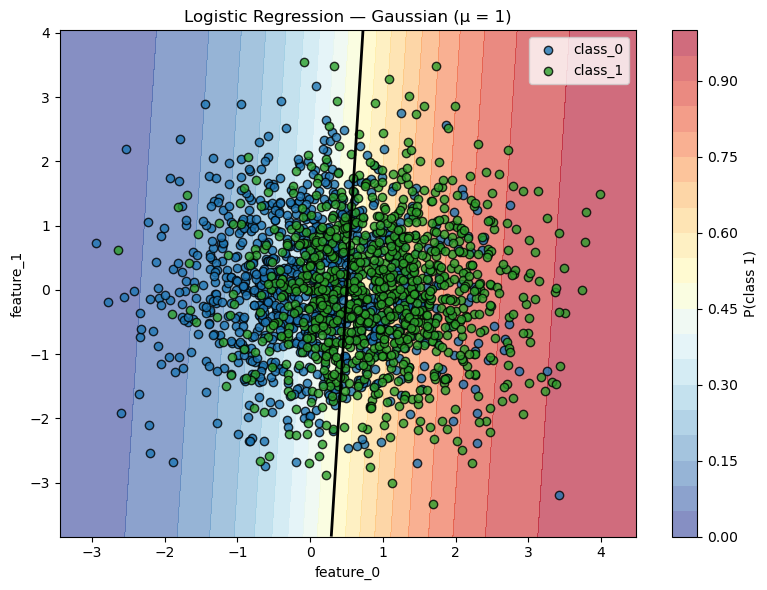

For μ = 1
[[704 296]
 [318 682]]
False Positive rate 0.148
False Negative rate 0.159
Accuracy = 69.30%


In [83]:
#μ = 1

mean4 = [1,0]
N_value = 1000
x_values5, y_values5 = np.random.multivariate_normal(mean1, covariance, N_value).T
x_values6, y_values6 = np.random.multivariate_normal(mean4, covariance, N_value).T

classarray2 = np.concatenate( (np.zeros(len(x_values5)), np.ones(len(x_values6)))).astype(int)
datalist2 = []
for i in np.arange(len(x_values5)):
    datalist2.append(np.array([x_values5[i],y_values5[i]]))

for j in np.arange(len(x_values6)):
    datalist2.append(np.array([x_values6[j],y_values6[j]]))
    
dataarray2 = np.array(datalist2)
#Get test data. I took a fifth of the data to be my test data.
test_data2 = dataarray2
test_class2 = classarray2
#Fit test data.
clf_lr2 = LogisticRegression()
clf_lr2.fit(test_data2, test_class2)

#print(f"Weights w = {clf_lr.coef_[0]}")
#print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
#print(f"Accuracy = {clf_lr1.score(test_data1, test_class1):.2%}")

my_dataset2 = Bunch(
    data=test_data2,
    target=test_class2,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )

plot_decision_boundary(
    clf_lr2, test_data2, test_class2,
    title='Logistic Regression — Gaussian (μ = 1)',
    feature_names= my_dataset2.feature_names[:2],
    class_names=list(my_dataset2.target_names[:2])
    )
plt.tight_layout()
plt.show()

class_pred2 = clf_lr2.predict(test_data2)
cm2 = confusion_matrix(test_class2, class_pred2)
print('For μ = 1')
print(cm2)
print('False Positive rate',cm2[0,1]/np.sum(cm2))
print('False Negative rate',cm2[1,0]/np.sum(cm2))
print(f"Accuracy = {clf_lr2.score(test_data2, test_class2):.2%}")
accuracy_array[2] = clf_lr2.score(test_data2, test_class2)

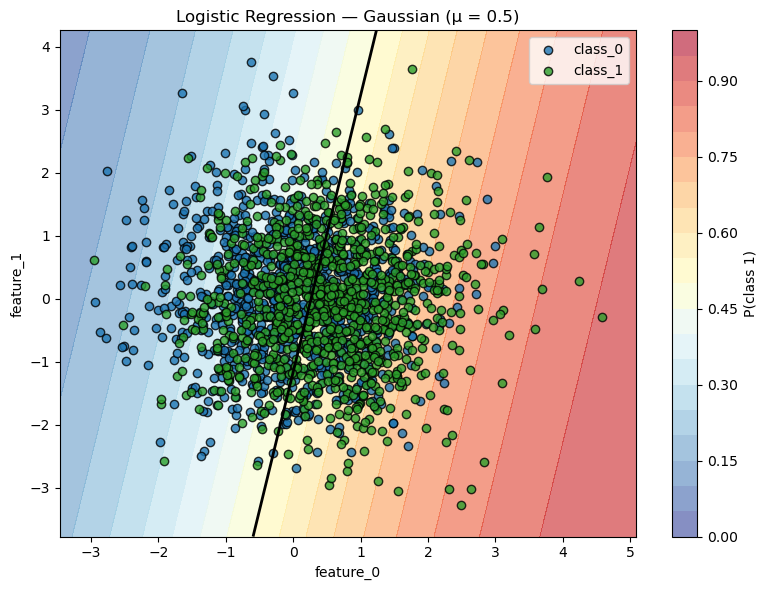

For μ = 0.5
[[592 408]
 [387 613]]
False Positive rate 0.204
False Negative rate 0.1935
Accuracy = 60.25%


In [85]:
#μ = 0.5

mean5 = [0.5,0]
N_value = 1000
x_values7, y_values7 = np.random.multivariate_normal(mean1, covariance, N_value).T
x_values8, y_values8 = np.random.multivariate_normal(mean5, covariance, N_value).T

classarray3 = np.concatenate( (np.zeros(len(x_values7)), np.ones(len(x_values8)))).astype(int)
datalist3 = []
for i in np.arange(len(x_values7)):
    datalist3.append(np.array([x_values7[i],y_values7[i]]))

for j in np.arange(len(x_values8)):
    datalist3.append(np.array([x_values8[j],y_values8[j]]))
    
dataarray3 = np.array(datalist3)
#Get test data. I took a fifth of the data to be my test data.
test_data3 = dataarray3
test_class3 = classarray3
#Fit test data.
clf_lr3 = LogisticRegression()
clf_lr3.fit(test_data3, test_class3)

#print(f"Weights w = {clf_lr.coef_[0]}")
#print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
#print(f"Accuracy = {clf_lr1.score(test_data1, test_class1):.2%}")

my_dataset3 = Bunch(
    data=test_data3,
    target=test_class3,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )

plot_decision_boundary(
    clf_lr3, test_data3, test_class3,
    title='Logistic Regression — Gaussian (μ = 0.5)',
    feature_names= my_dataset3.feature_names[:2],
    class_names=list(my_dataset3.target_names[:2])
    )
plt.tight_layout()
plt.show()

class_pred3 = clf_lr3.predict(test_data3)
cm3 = confusion_matrix(test_class3, class_pred3)
print('For μ = 0.5')
print(cm3)
print('False Positive rate',cm3[0,1]/np.sum(cm3))
print('False Negative rate',cm3[1,0]/np.sum(cm3))
print(f"Accuracy = {clf_lr3.score(test_data3, test_class3):.2%}")
accuracy_array[3] = clf_lr3.score(test_data3, test_class3)

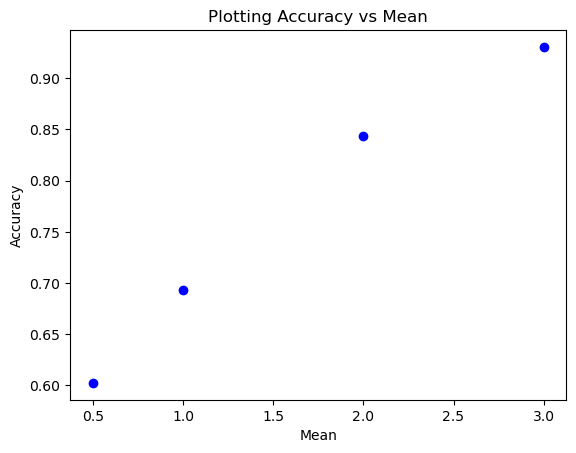

In [87]:
fig, ax = plt.subplots()

plt.scatter(mean_array, accuracy_array, c='b')
plt.title('Plotting Accuracy vs Mean')
plt.xlabel('Mean')
plt.ylabel('Accuracy')

plt.show()

Question 4 for the Homework 4

1. Why does performance degrade as μ -> 0?
    The accuracy decreases as the mean decreases because the centers of the two distributions are getting closer and closer. This means that given their covariances are the same, the two distributions are overlapping each other more and more. Thus it becomes harder and harder to separate the two data sets without more and more false classifications.

2. Does adding more data help when μ = 0?
    Adding more data could not help when the mean of the two distributions are the same. Given that covariances are already the same, there is simply no differences between the two data sets. They are the same distribution, so there's no way you can use a linear classifier to accurately separated them. It won't matter if you increase the number of points of the data, because this fact about the two distributions won't change. 


3. What assumption does a linear classifier make about the data?
    The key assumption made by a linear classifier is that it assumes the best method of separating two classes is drawing a straight line through the data. This doesn't take into account situations where a curved line, some kind of shape, etc... might be a better fit for the data. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})

# reproducibility
RNG = np.random.default_rng(42)


In [2]:
mean_0 = [0, 0]
mean_3 = [3, 0]
cov_I = [[1, 0], [0, 1]]

size = 500

data_0 = np.random.multivariate_normal(mean_0, cov_I, size)
data_3 = np.random.multivariate_normal(mean_3, cov_I, size)

x0, y0 = data_0.T
x3, y3 = data_3.T

In [3]:
# test my class
import numpy as np
from sklearn.utils import Bunch

# 1. Combine the features into one array (X)
X = np.vstack((data_0, data_3))

# 2. Create the labels (y)
# 500 zeros followed by 500 ones
y = np.concatenate((np.zeros(size), np.ones(size)))

# 3. Wrap it in a Bunch object
my_dataset = Bunch(
    data=X,
    target=y.astype(int),
    target_names=np.array(['class_0', 'class_3']),
    feature_names=['x_feature', 'y_feature'],
    DESCR="A custom 2D Gaussian dataset"
)

# Now you can use it just like iris!
print(my_dataset.data.shape)  # (1000, 2)
print(my_dataset.target.shape) # (1000,)

(1000, 2)
(1000,)


In [4]:
mask = my_dataset.target != 2
X_my = my_dataset.data[mask][:, :2]
y_my = my_dataset.target[mask]

print(f"Features: {my_dataset.feature_names[:2]}")
print(f"Classes:  {my_dataset.target_names[:2]}")
print(f"Samples:  {len(y_my)}  (class 0: {(y_my==0).sum()}, class 3: {(y_my==1).sum()})")

Features: ['x_feature', 'y_feature']
Classes:  ['class_0' 'class_3']
Samples:  1000  (class 0: 500, class 3: 500)


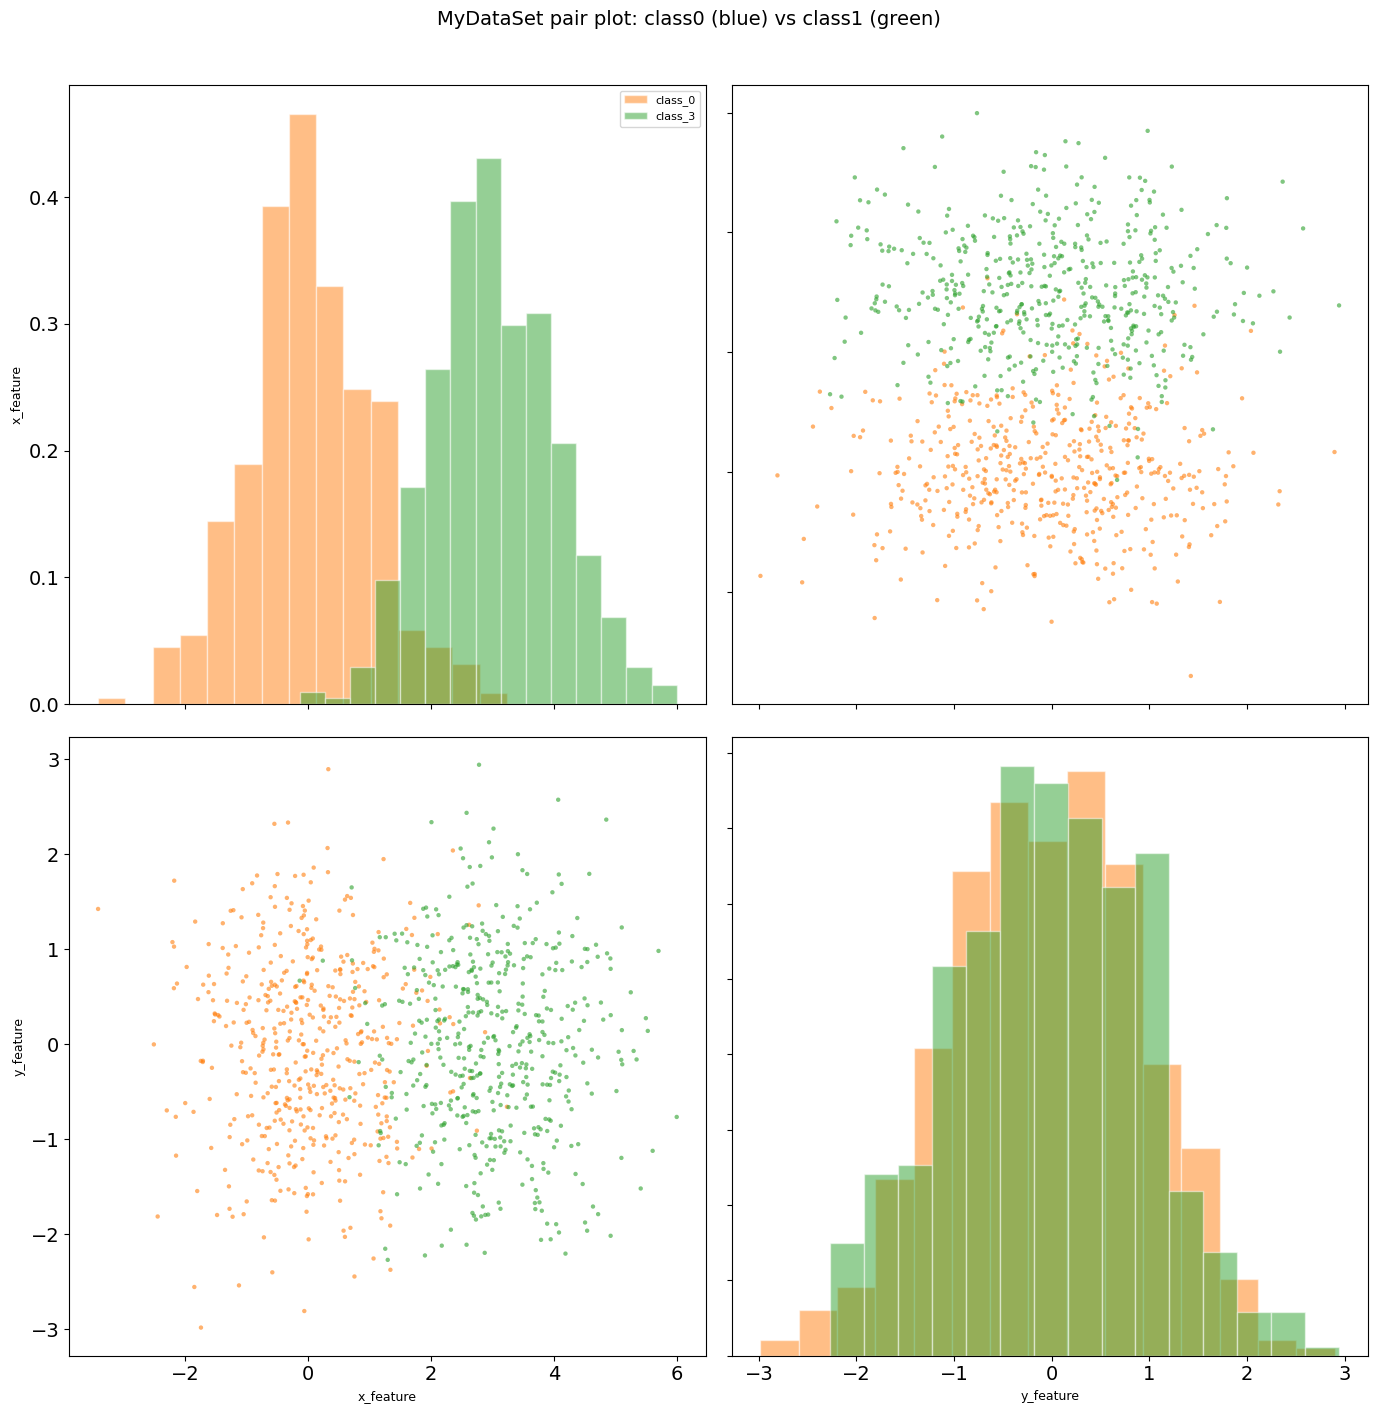

In [5]:
# Full pair plot of all 2 features for the two classes
n_features = 2
feature_names_all = my_dataset.feature_names
class_colors = {0: 'tab:orange', 1: 'tab:green'}
class_labels = {0: my_dataset.target_names[0], 1: my_dataset.target_names[1]}

# Use full 4-feature data for both classes
mask_full = my_dataset.target != 2
X_full = my_dataset.data[mask_full]
y_full = my_dataset.target[mask_full]

fig, axes = plt.subplots(n_features, n_features, figsize=(14, 14))

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            # Diagonal: 1D histograms
            for c in [0, 1]:
                sel = y_full == c
                ax.hist(X_full[sel, i], bins=15, alpha=0.5, density=True,
                        color=class_colors[c], label=class_labels[c], edgecolor='white')
            if i == 0:
                ax.legend(fontsize=8)
        else:
            # Off-diagonal: scatter plots
            for c in [0, 1]:
                sel = y_full == c
                ax.scatter(X_full[sel, j], X_full[sel, i], c=class_colors[c],
                           s=10, alpha=0.6, edgecolors='none')

        # Labels on edges only
        if i == n_features - 1:
            ax.set_xlabel(feature_names_all[j], fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(feature_names_all[i], fontsize=9)
        else:
            ax.set_yticklabels([])

fig.suptitle('MyDataSet pair plot: class0 (blue) vs class1 (green)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

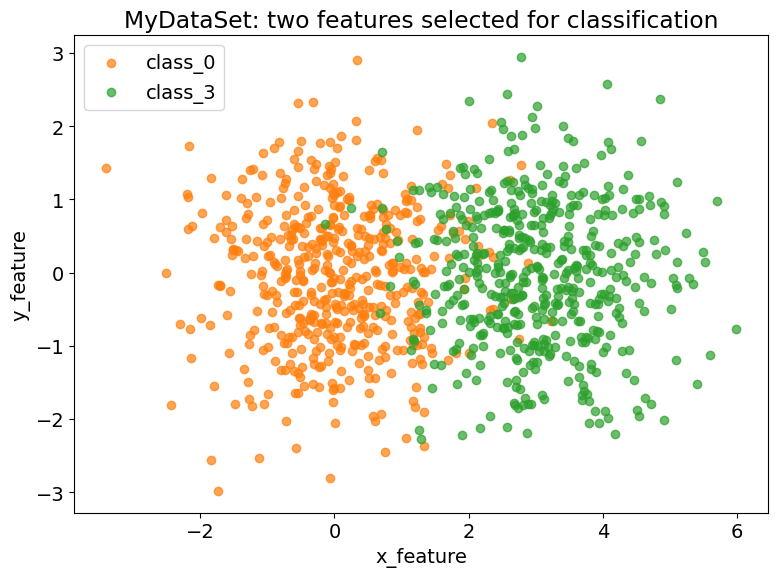

In [6]:
# Quick scatter of just the two features we'll use for classification
fig, ax = plt.subplots()
for c, name, color in zip([0, 1], my_dataset.target_names[:2], ['tab:orange', 'tab:green']):
    sel = y_my == c
    ax.scatter(X_my[sel, 0], X_my[sel, 1], label=name, c=color, alpha=0.7)
ax.set_xlabel(my_dataset.feature_names[0])
ax.set_ylabel(my_dataset.feature_names[1])
ax.legend()
ax.set_title('MyDataSet: two features selected for classification')
plt.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_my, y_my, test_size=0.3, random_state=42
)
print(f"Training samples: {len(y_train)},  Test samples: {len(y_test)}")

Training samples: 700,  Test samples: 300


In [8]:
# test
clf_lr = LogisticRegression()
clf_lr.fit(X_train, y_train)

print(f"Weights w = {clf_lr.coef_[0]}")
print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
print(f"\nTest accuracy = {clf_lr.score(X_test, y_test):.2%}")


Weights w = [ 2.76447872 -0.05582547]
Bias    b = -4.196

Test accuracy = 94.00%


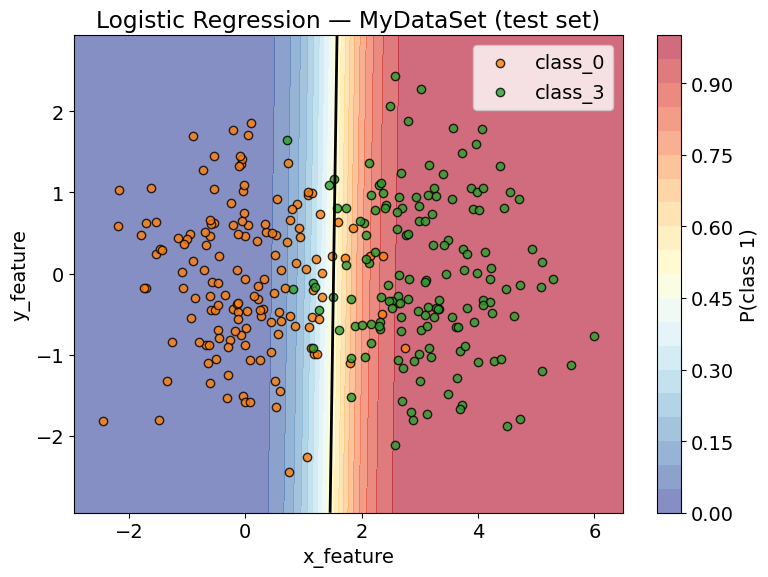

In [9]:
# Decision Boundary
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # predict probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    # plot
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)

    colors = ['tab:orange', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)

    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='P(class 1)')
    return ax

plot_decision_boundary(
    clf_lr, X_test, y_test,
    title='Logistic Regression — MyDataSet (test set)',
    feature_names = my_dataset.feature_names[:2],
    class_names=list(my_dataset.target_names[:2])
)
plt.tight_layout()
plt.show()


## Problem 3

For $\mu$ = 3

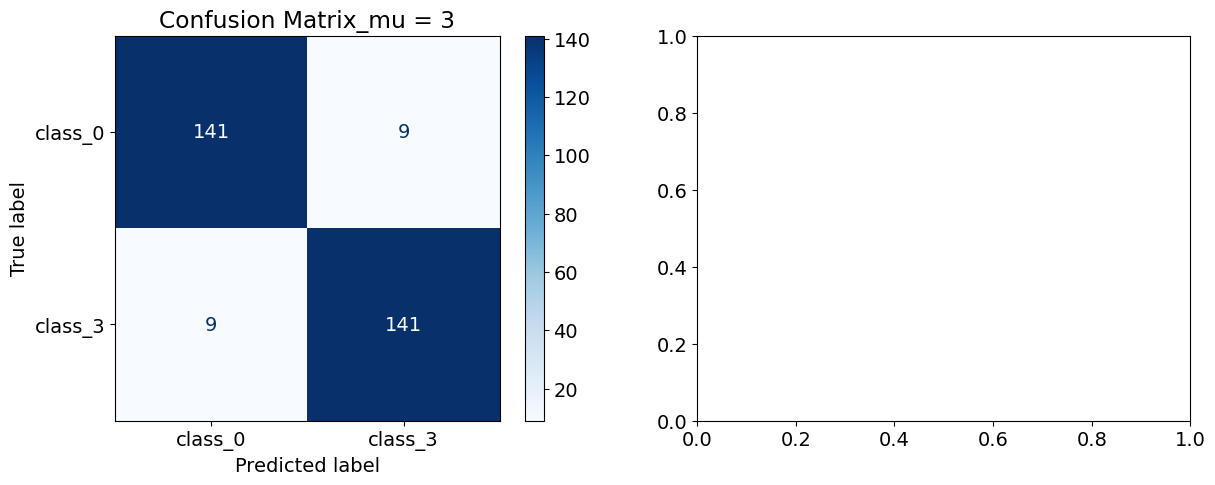

In [10]:
# for mu = 3

y_pred = clf_lr.predict(X_test)
y_prob = clf_lr.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_3 = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_3, display_labels=my_dataset.target_names[:2]).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix_mu = 3')
plt.show()

In [12]:
# my false negative
FP = cm_3[1, 0]/np.sum(cm_3)
FP
print(f"False Positive Percentage: {FP:.2%}")

# my false positive
FN = cm_3[0, 1]/np.sum(cm_3)
FN
print(f"False Negative Percentage: {FN:.2%}")

False Positive Percentage: 3.00%
False Negative Percentage: 3.00%


For $\mu$ = 2

In [13]:
# mu = 2 case

mean_2 = [2, 0]

data_0 = np.random.multivariate_normal(mean_0, cov_I, size)
data_2 = np.random.multivariate_normal(mean_2, cov_I, size)

x0, y0 = data_0.T
x2, y2 = data_2.T

In [14]:
X_2 = np.vstack((data_0, data_2))

y_2 = np.concatenate((np.zeros(size), np.ones(size)))

my_dataset_2 = Bunch(
    data=X_2,
    target=y_2.astype(int),
    target_names=np.array(['class_0', 'class_2']),
    feature_names=['x_feature', 'y_feature'],
    DESCR="A custom 2D Gaussian dataset"
)

print(my_dataset_2.data.shape)  # (1000, 2)
print(my_dataset_2.target.shape) # (1000,)

(1000, 2)
(1000,)


In [15]:
mask_2 = my_dataset_2.target != 2
X_my_2 = my_dataset_2.data[mask_2][:, :2]
y_my_2 = my_dataset_2.target[mask_2]

print(f"Features: {my_dataset_2.feature_names[:2]}")
print(f"Classes:  {my_dataset_2.target_names[:2]}")
print(f"Samples:  {len(y_my_2)}  (class 0: {(y_my_2==0).sum()}, class 1: {(y_my_2==1).sum()})")

Features: ['x_feature', 'y_feature']
Classes:  ['class_0' 'class_2']
Samples:  1000  (class 0: 500, class 1: 500)


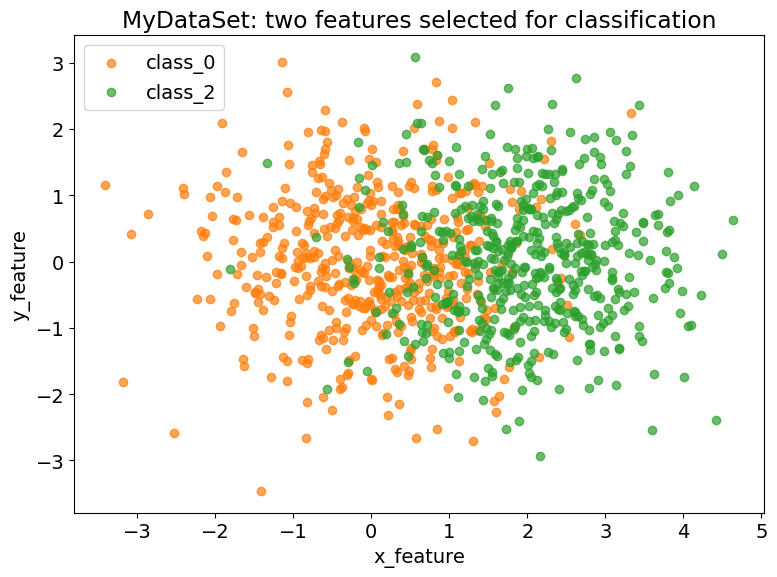

In [16]:
fig, ax = plt.subplots()
for c, name, color in zip([0, 1], my_dataset_2.target_names[:2], ['tab:orange', 'tab:green']):
    sel = y_my == c
    ax.scatter(X_my_2[sel, 0], X_my_2[sel, 1], label=name, c=color, alpha=0.7)
ax.set_xlabel(my_dataset_2.feature_names[0])
ax.set_ylabel(my_dataset_2.feature_names[1])
ax.legend()
ax.set_title('MyDataSet: two features selected for classification')
plt.tight_layout()
plt.show()

In [17]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_my_2, y_my_2, test_size=0.3, random_state=42
)
# I wanted to split the training and test a bit different from before but I'm not sure if it will change the
print(f"Training samples: {len(y_train_2)},  Test samples: {len(y_test_2)}")

Training samples: 700,  Test samples: 300


In [18]:
clf_lr = LogisticRegression()
clf_lr.fit(X_train_2, y_train_2)

print(f"Weights w = {clf_lr.coef_[0]}")
print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
print(f"\nTest accuracy = {clf_lr.score(X_test_2, y_test_2):.2%}")

Weights w = [1.75479377 0.00880592]
Bias    b = -1.756

Test accuracy = 88.67%


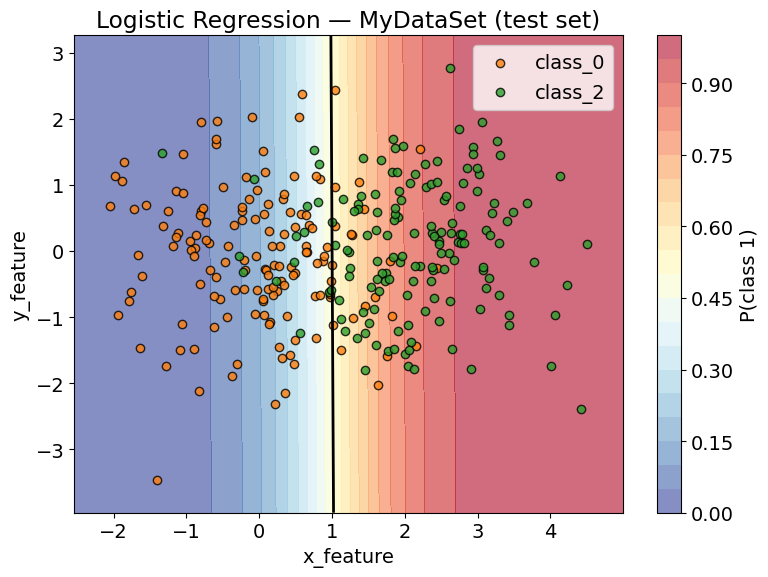

In [20]:
# Decision Boundary
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # predict probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    # plot
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)

    colors = ['tab:orange', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)

    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='P(class 1)')
    return ax

plot_decision_boundary(
    clf_lr, X_test_2, y_test_2,
    title='Logistic Regression — MyDataSet (test set)',
    feature_names = my_dataset_2.feature_names[:2],
    class_names=list(my_dataset_2.target_names[:2])
)
plt.tight_layout()
plt.show()

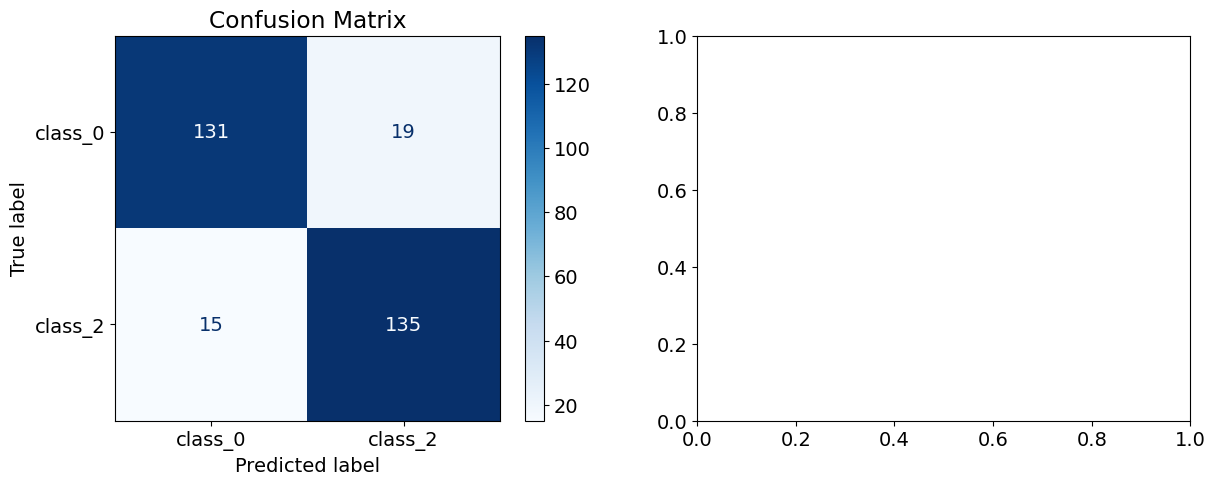

In [21]:
y_pred_2 = clf_lr.predict(X_test_2)
y_prob_2 = clf_lr.predict_proba(X_test_2)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_2 = confusion_matrix(y_test_2, y_pred_2)
ConfusionMatrixDisplay(cm_2, display_labels=my_dataset_2.target_names[:2]).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

plt.show()

In [23]:
# cm_2[1, 0]

In [25]:
# my false negative
FP_2 = cm_2[1, 0]/np.sum(cm_2)
FP_2
print(f"False Positive Percentage: {FP_2:.2%}")

# my false positive
FN_2 = cm_2[0, 1]/np.sum(cm_2)
FN_2
print(f"False Negative Percentage: {FN_2:.2%}")

False Positive Percentage: 5.00%
False Negative Percentage: 6.33%


For $\mu$ = 1

In [26]:
# mu = 1 case

mean_1 = [1, 0]

data_0 = np.random.multivariate_normal(mean_0, cov_I, size)
data_1 = np.random.multivariate_normal(mean_1, cov_I, size)

x0, y0 = data_0.T
x1, y1 = data_1.T

In [27]:
X_1 = np.vstack((data_0, data_1))

y_1 = np.concatenate((np.zeros(size), np.ones(size)))

my_dataset_1 = Bunch(
    data=X_1,
    target=y_1.astype(int),
    target_names=np.array(['class_0', 'class_1']),
    feature_names=['x_feature', 'y_feature'],
    DESCR="A custom 2D Gaussian dataset"
)

print(my_dataset_1.data.shape)  # (1000, 2)
print(my_dataset_1.target.shape) # (1000,)

(1000, 2)
(1000,)


In [28]:
mask_1 = my_dataset_1.target != 2
X_my_1 = my_dataset_1.data[mask_1][:, :2]
y_my_1 = my_dataset_1.target[mask_1]

print(f"Features: {my_dataset_1.feature_names[:2]}")
print(f"Classes:  {my_dataset_1.target_names[:2]}")
print(f"Samples:  {len(y_my_1)}  (class 0: {(y_my_1==0).sum()}, class 1: {(y_my_1==1).sum()})")

Features: ['x_feature', 'y_feature']
Classes:  ['class_0' 'class_1']
Samples:  1000  (class 0: 500, class 1: 500)


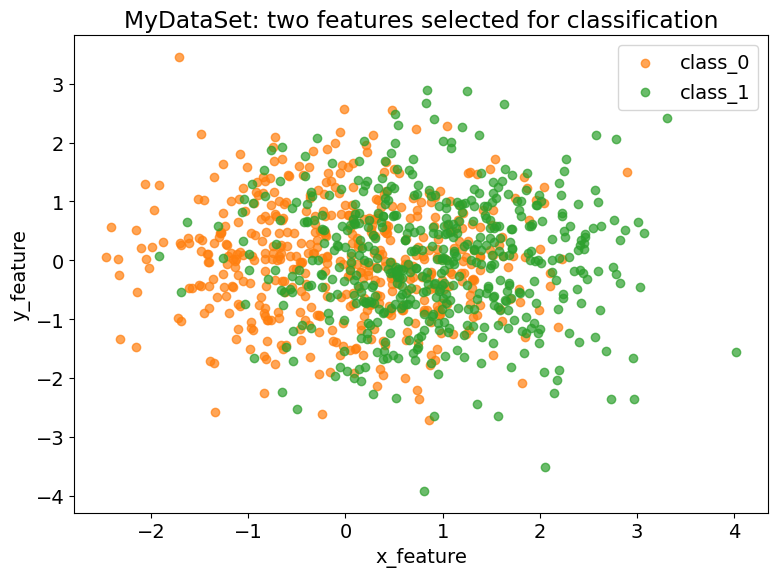

In [29]:
fig, ax = plt.subplots()
for c, name, color in zip([0, 1], my_dataset_1.target_names[:2], ['tab:orange', 'tab:green']):
    sel = y_my == c
    ax.scatter(X_my_1[sel, 0], X_my_1[sel, 1], label=name, c=color, alpha=0.7)
ax.set_xlabel(my_dataset_1.feature_names[0])
ax.set_ylabel(my_dataset_1.feature_names[1])
ax.legend()
ax.set_title('MyDataSet: two features selected for classification')
plt.tight_layout()
plt.show()

In [30]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_my_1, y_my_1, test_size=0.3, random_state=42
)
# I wanted to split the training and test a bit different from before but I'm not sure if it will change the
print(f"Training samples: {len(y_train_1)},  Test samples: {len(y_test_1)}")

Training samples: 700,  Test samples: 300


In [31]:
clf_lr = LogisticRegression()
clf_lr.fit(X_train_1, y_train_1)

print(f"Weights w = {clf_lr.coef_[0]}")
print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
print(f"\nTest accuracy = {clf_lr.score(X_test_1, y_test_1):.2%}")

Weights w = [ 0.88468619 -0.00280846]
Bias    b = -0.403

Test accuracy = 71.67%


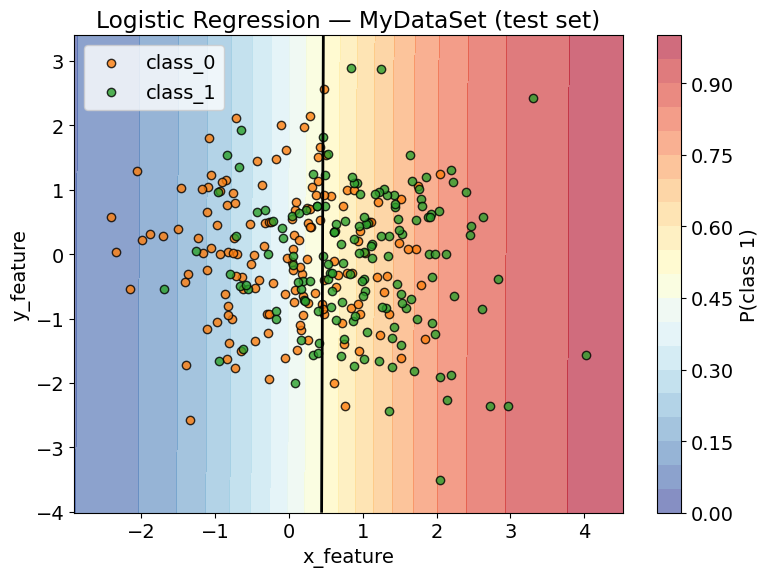

In [32]:
# Decision Boundary
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # predict probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    # plot
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)

    colors = ['tab:orange', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)

    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='P(class 1)')
    return ax

plot_decision_boundary(
    clf_lr, X_test_1, y_test_1,
    title='Logistic Regression — MyDataSet (test set)',
    feature_names = my_dataset_1.feature_names[:2],
    class_names=list(my_dataset_1.target_names[:2])
)
plt.tight_layout()
plt.show()

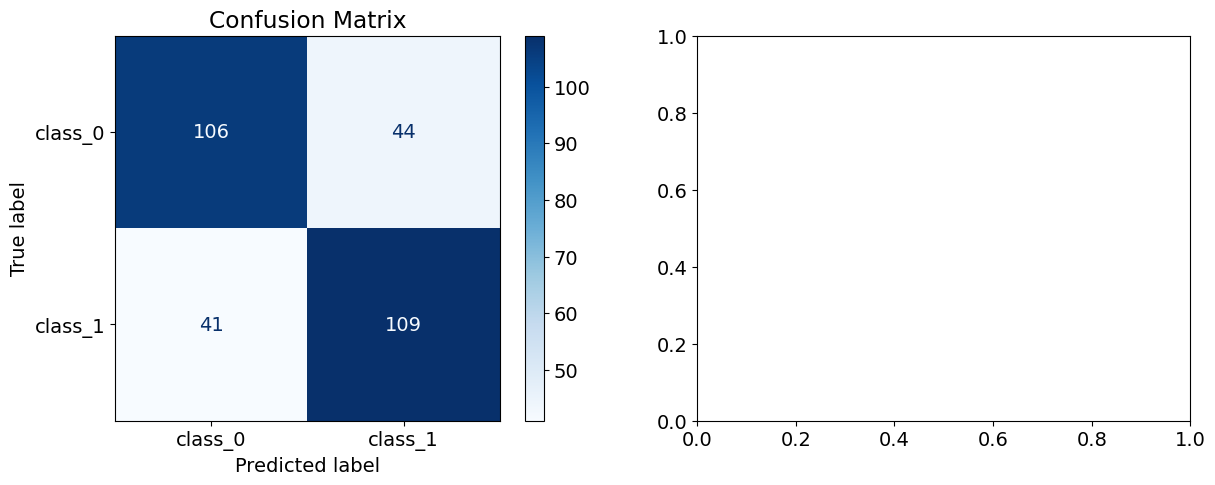

In [33]:
y_pred_1 = clf_lr.predict(X_test_1)
y_prob_1 = clf_lr.predict_proba(X_test_1)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_1 = confusion_matrix(y_test_1, y_pred_1)
ConfusionMatrixDisplay(cm_1, display_labels=my_dataset_1.target_names[:2]).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

plt.show()

In [34]:
# my false negative
FP_1 = cm_1[1, 0]/np.sum(cm_1)
FP_1
print(f"False Positive Percentage: {FP_1:.2%}")

# my false positive
FN_1 = cm_1[0, 1]/np.sum(cm_1)
FN_1
print(f"False Negative Percentage: {FN_1:.2%}")

False Positive Percentage: 13.67%
False Negative Percentage: 14.67%


For $\mu$ = 0.5

In [35]:
# mu = 0.5 case

mean_half = [0.5, 0]

data_half = np.random.multivariate_normal(mean_half, cov_I, size)

xhalf, yhalf = data_half.T

In [36]:
X_half = np.vstack((data_0, data_half))

y_half = np.concatenate((np.zeros(size), np.ones(size)))

my_dataset_half = Bunch(
    data=X_half,
    target=y_half.astype(int),
    target_names=np.array(['class_0', 'class_0.5']),
    feature_names=['x_feature', 'y_feature'],
    DESCR="A custom 2D Gaussian dataset"
)

print(my_dataset_half.data.shape)  # (1000, 2)
print(my_dataset_half.target.shape) # (1000,)

mask_half = my_dataset_half.target != 2
X_my_half = my_dataset_half.data[mask_half][:, :2]
y_my_half = my_dataset_half.target[mask_half]

print(f"Features: {my_dataset_half.feature_names[:2]}")
print(f"Classes:  {my_dataset_half.target_names[:2]}")
print(f"Samples:  {len(y_my_half)}  (class 0: {(y_my_half==0).sum()}, class 1: {(y_my_half==1).sum()})")

(1000, 2)
(1000,)
Features: ['x_feature', 'y_feature']
Classes:  ['class_0' 'class_0.5']
Samples:  1000  (class 0: 500, class 1: 500)


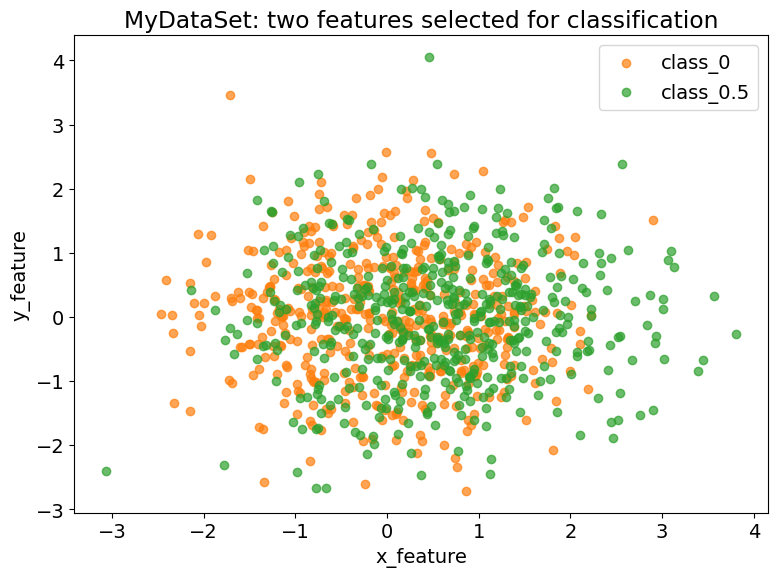

In [37]:
fig, ax = plt.subplots()
for c, name, color in zip([0, 1], my_dataset_half.target_names[:2], ['tab:orange', 'tab:green']):
    sel = y_my == c
    ax.scatter(X_my_half[sel, 0], X_my_half[sel, 1], label=name, c=color, alpha=0.7)
ax.set_xlabel(my_dataset_half.feature_names[0])
ax.set_ylabel(my_dataset_half.feature_names[1])
ax.legend()
ax.set_title('MyDataSet: two features selected for classification')
plt.tight_layout()
plt.show()

In [38]:
X_train_half, X_test_half, y_train_half, y_test_half = train_test_split(
    X_my_half, y_my_half, test_size=0.3, random_state=42
)
# I wanted to split the training and test a bit different from before but I'm not sure if it will change the
print(f"Training samples: {len(y_train_half)},  Test samples: {len(y_test_half)}")

clf_lr = LogisticRegression()
clf_lr.fit(X_train_half, y_train_half)

print(f"Weights w = {clf_lr.coef_[0]}")
print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
print(f"\nTest accuracy = {clf_lr.score(X_test_half, y_test_half):.2%}")

Training samples: 700,  Test samples: 300
Weights w = [ 0.47484093 -0.0390265 ]
Bias    b = -0.135

Test accuracy = 64.00%


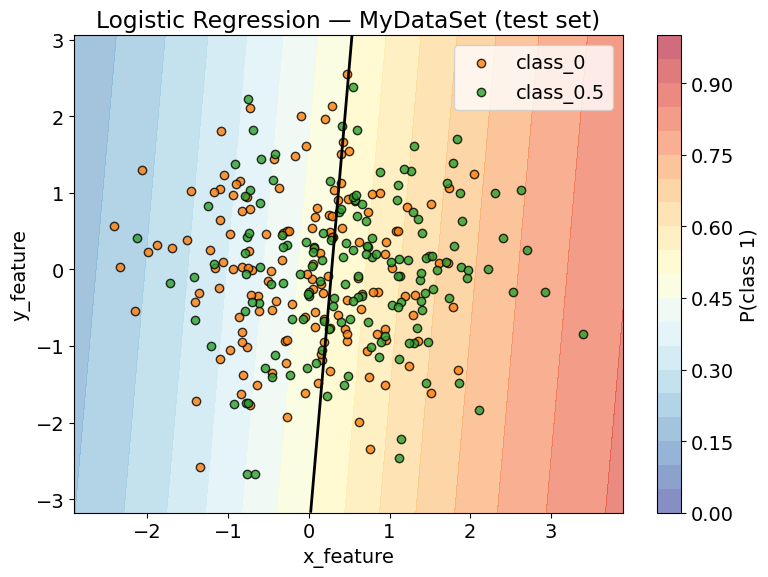

In [39]:
# Decision Boundary
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # predict probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    # plot
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)

    colors = ['tab:orange', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)

    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='P(class 1)')
    return ax

plot_decision_boundary(
    clf_lr, X_test_half, y_test_half,
    title='Logistic Regression — MyDataSet (test set)',
    feature_names = my_dataset_half.feature_names[:2],
    class_names=list(my_dataset_half.target_names[:2])
)
plt.tight_layout()
plt.show()

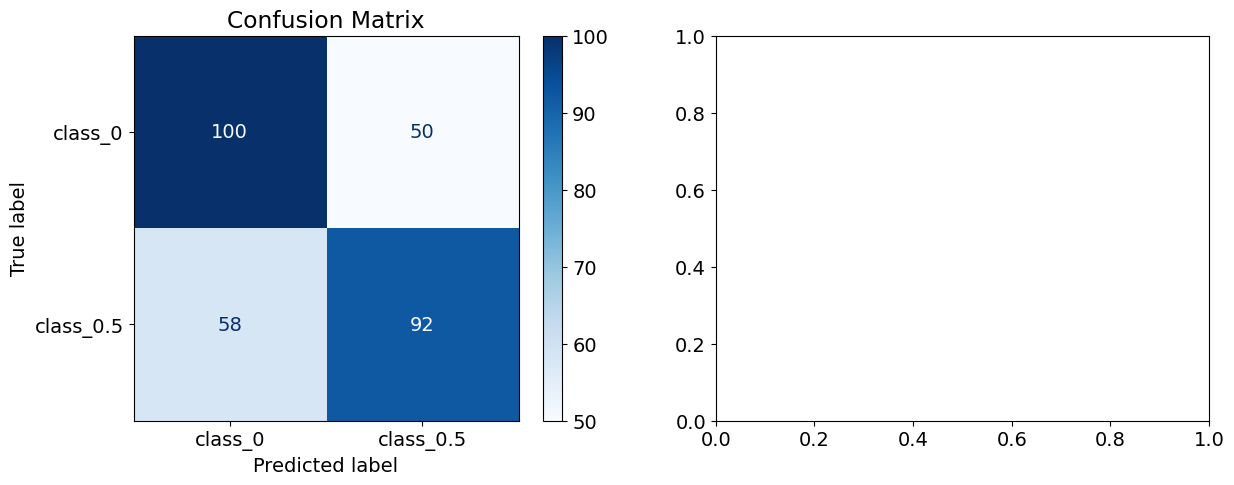

In [40]:
y_pred_half = clf_lr.predict(X_test_half)
y_prob_half = clf_lr.predict_proba(X_test_half)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_half = confusion_matrix(y_test_half, y_pred_half)
ConfusionMatrixDisplay(cm_half, display_labels=my_dataset_half.target_names[:2]).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

plt.show()

In [41]:
# my false negative
FP_half = cm_half[1, 0]/np.sum(cm_half)
FP_half
print(f"False Positive Percentage: {FP_half:.2%}")

# my false positive
FN_half = cm_half[0, 1]/np.sum(cm_half)
FN_half
print(f"False Negative Percentage: {FN_half:.2%}")

False Positive Percentage: 19.33%
False Negative Percentage: 16.67%


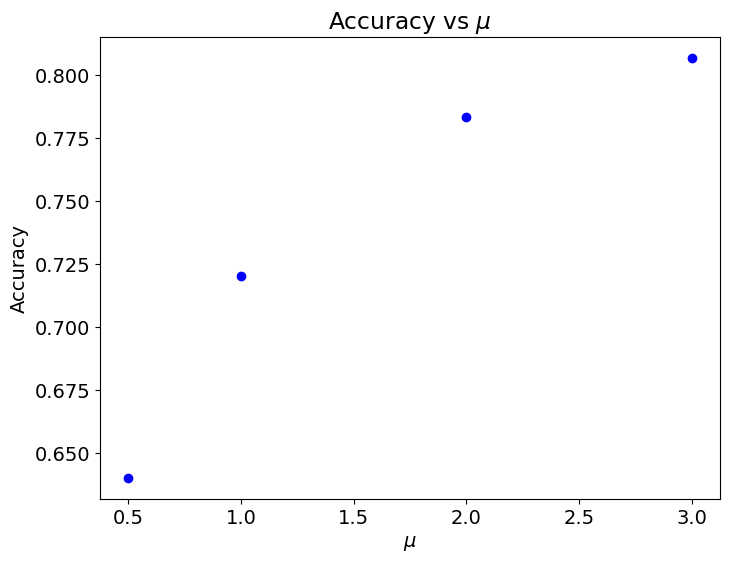

In [42]:
mu_array = [0.5, 1, 2, 3]
accuracy_array = [clf_lr.score(X_test_half, y_test_half), clf_lr.score(X_test_1, y_test_1), clf_lr.score(X_test_2, y_test_2), clf_lr.score(X_test, y_test)]
accuracy_array
plt.scatter(mu_array, accuracy_array, c='blue')
plt.title('Accuracy vs $\mu$')
plt.xlabel(r'$\mu$')
plt.ylabel('Accuracy')
plt.show()


## Problem 4

1. From the Logistic Regression Gaussian Plots, with higher $\mu$, the data points from different classes overlap less. On the other hand, when $\mu$ is closer to zero, data points from different classses overlap a lot, which makes it harder to accurataly classify them. Hence, wiht a lower $\mu$, we have a lower accuracy rate.

2. This is inspired from the discussion wtih Luke(Luke, 2026): if two data sets have the same $\mu$ and same covariance (in this case, both mu are zero), they can be considered or classified as same distribution. Hence, adding more data points are expected to not change any disctribution therefore not improve the accuracy rate.


3. From our Logistic Regression Gaussian Plots, we always used a straght line to seperate two data sets. In other words, the assumption that a linear classifier makes is that a straight line (regardless of its slope) is sufficient to accuratly classify two data sets with two features.